# Emotion Classification with RNNs, LSTMs & GRUs

We will classify text into six emotions: **sadness, joy, love, anger, fear, surprise**.

We first compare foundational recurrent models and then build an **Advanced Bidirectional GRU**. The dataset already provides separate train, validation, and test splits, so the test set will be kept untouched until final evaluation.

## 1. Import Libraries

Import NumPy, Pandas, visualization tools, TensorFlow/Keras, Hugging Face Datasets, and evaluation utilities.

In [95]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from datasets import load_dataset

from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN,
    Embedding,
    Dense,
    Dropout,
    LSTM,
    GRU,
    Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping




## 2. Load Dataset

We use the **dair-ai/emotion** dataset from Hugging Face. It contains six emotion classes and provides separate **train**, **validation**, and **test** splits.

Dataset link: [dair-ai/emotion](https://huggingface.co/datasets/dair-ai/emotion)


In [96]:
emotion_dataset = load_dataset('dair-ai/emotion')
emotion_dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [97]:
# Extract all three official splits
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

validation_text = emotion_dataset['validation']['text']
validation_label = emotion_dataset['validation']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

print('Train samples:', len(train_text))
print('Validation samples:', len(validation_text))
print('Test samples:', len(test_text))


Train samples: 16000
Validation samples: 2000
Test samples: 2000


In [98]:
label_names = emotion_dataset['train'].features['label'].names
label_names


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [99]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})

df_validation = pd.DataFrame({
    'text': validation_text,
    'label': [label_names[i] for i in validation_label]
})

df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

print('Train shape:', df_train.shape)
print('Validation shape:', df_validation.shape)
print('Test shape:', df_test.shape)


Train shape: (16000, 2)
Validation shape: (2000, 2)
Test shape: (2000, 2)


In [100]:
# Check for missing values
print('Train missing values:')
print(df_train.isnull().sum())

print('\nValidation missing values:')
print(df_validation.isnull().sum())

print('\nTest missing values:')
print(df_test.isnull().sum())


Train missing values:
text     0
label    0
dtype: int64

Validation missing values:
text     0
label    0
dtype: int64

Test missing values:
text     0
label    0
dtype: int64


## 3. Exploratory Data Analysis (EDA)

Visualize the class distribution and inspect the training data.

In [101]:
df_train.shape, df_validation.shape, df_test.shape


((16000, 2), (2000, 2), (2000, 2))

In [102]:
df_train['label'].value_counts()


,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


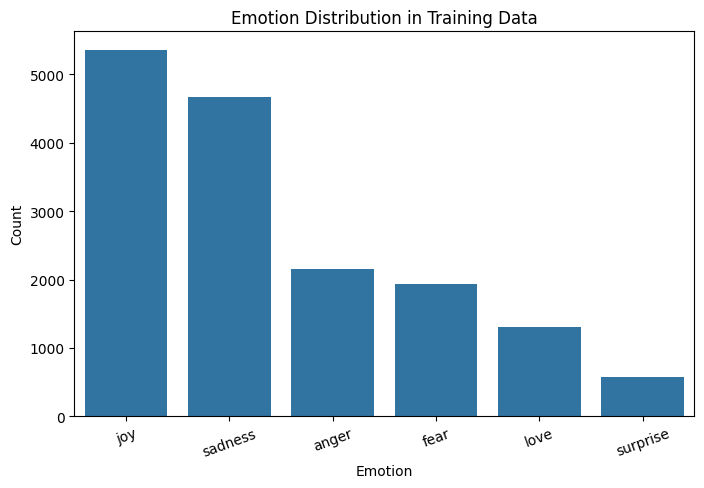

In [103]:
plt.figure(figsize=(8, 5))
sns.countplot(
    x='label',
    data=df_train,
    order=df_train['label'].value_counts().index
)
plt.title('Emotion Distribution in Training Data')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.show()


In [104]:
df_train.head()


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## 4. Data Preprocessing - Using NLP

Tokenize the text using a Keras tokenizer fitted **only on training text**. Then convert text to integer sequences and pad/truncate every sequence to a fixed length of 50.

In [106]:
max_words = 10000
max_length = 50

# Fit tokenizer only on training data
tokenizer = Tokenizer(
    num_words=max_words,
    oov_token='<OOV>'
)
tokenizer.fit_on_texts(df_train['text'])

# Convert text to integer sequences
train_sequence = tokenizer.texts_to_sequences(df_train['text'])
validation_sequence = tokenizer.texts_to_sequences(df_validation['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

# Pad / truncate sequences
padded_train_sequence = pad_sequences(
    train_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

padded_validation_sequence = pad_sequences(
    validation_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

padded_test_sequence = pad_sequences(
    test_sequence,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

train_labels = np.array(train_label)
validation_labels = np.array(validation_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))

print('Vocabulary Size:', len(tokenizer.word_index))
print('Max Sequence Length:', max_length)
print('Number of Classes:', num_classes)
print('Train shape:', padded_train_sequence.shape)
print('Validation shape:', padded_validation_sequence.shape)
print('Test shape:', padded_test_sequence.shape)


Vocabulary Size: 15213
Max Sequence Length: 50
Number of Classes: 6
Train shape: (16000, 50)
Validation shape: (2000, 50)
Test shape: (2000, 50)


## 5. Shared Training Utilities

Use balanced class weights to handle class imbalance. Early stopping monitors **validation loss**, not test loss. The test set is not passed to training.

In [107]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))
class_weight_dict


{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [108]:
def make_early_stopping():
    return EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )


## 6. Phase 1 — Plain Foundational Models

Train plain (non-bidirectional) **Simple RNN, LSTM, and GRU** models. Validation data is used during training for early stopping and model comparison.

### 6.1 Model 1 — Simple RNN

Plain stacked recurrent neural network.

In [109]:
rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_length),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [110]:
rnn_history = rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_validation_sequence, validation_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()]
)

rnn_val_loss, rnn_val_accuracy = rnn_model.evaluate(
    padded_validation_sequence,
    validation_labels,
    verbose=0
)

print(f'RNN Validation Loss: {rnn_val_loss:.4f}')
print(f'RNN Validation Accuracy: {rnn_val_accuracy:.4f}')


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.1670 - loss: 1.9056 - val_accuracy: 0.1895 - val_loss: 1.7862
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1643 - loss: 1.7996 - val_accuracy: 0.1110 - val_loss: 1.8084
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1600 - loss: 1.7871 - val_accuracy: 0.1995 - val_loss: 1.7841
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1710 - loss: 1.7693 - val_accuracy: 0.1275 - val_loss: 1.7935
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1643 - loss: 1.7536 - val_accuracy: 0.1115 - val_loss: 1.7976
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1736 - loss: 1.7343 - val_accuracy: 0.1360 - val_loss: 1.8217
RNN Validation Loss: 1.7841
RNN Validation Accuracy: 0.1995


### 6.2 Model 2 — Standard LSTM

Plain stacked Long Short-Term Memory network.

In [111]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_length),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [112]:
lstm_history = lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_validation_sequence, validation_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()]
)

lstm_val_loss, lstm_val_accuracy = lstm_model.evaluate(
    padded_validation_sequence,
    validation_labels,
    verbose=0
)

print(f'LSTM Validation Loss: {lstm_val_loss:.4f}')
print(f'LSTM Validation Accuracy: {lstm_val_accuracy:.4f}')


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1471 - loss: 1.7959 - val_accuracy: 0.0415 - val_loss: 1.8067
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1399 - loss: 1.7933 - val_accuracy: 0.3430 - val_loss: 1.7813
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1459 - loss: 1.7930 - val_accuracy: 0.3390 - val_loss: 1.7664
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1696 - loss: 1.7671 - val_accuracy: 0.1465 - val_loss: 1.8013
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3302 - loss: 1.5203 - val_accuracy: 0.5815 - val_loss: 1.2071
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.6894 - loss: 0.9570 - val_accuracy: 0.7980 - val_loss: 0.7368
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8403 - loss: 0.5682 - val_accuracy: 0.8715 - val_loss: 0.5110
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8788 - loss: 0.4481 - val_accu

### 6.3 Model 3 — Standard GRU

Plain stacked Gated Recurrent Unit network.

In [113]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_length),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_10 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_11 (GRU)                    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [114]:
gru_history = gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_validation_sequence, validation_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()]
)

gru_val_loss, gru_val_accuracy = gru_model.evaluate(
    padded_validation_sequence,
    validation_labels,
    verbose=0
)

print(f'GRU Validation Loss: {gru_val_loss:.4f}')
print(f'GRU Validation Accuracy: {gru_val_accuracy:.4f}')


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.1661 - loss: 1.7974 - val_accuracy: 0.3510 - val_loss: 1.7695
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1529 - loss: 1.7958 - val_accuracy: 0.2755 - val_loss: 1.7891
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1523 - loss: 1.7950 - val_accuracy: 0.2745 - val_loss: 1.7933
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1576 - loss: 1.7935 - val_accuracy: 0.1055 - val_loss: 1.7907
GRU Validation Loss: 1.7695
GRU Validation Accuracy: 0.3510


### 6.4 Phase 1 Ranking & Selection

Rank the three foundational models using **validation accuracy**. The test set is deliberately not used here.

In [115]:
result_df = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Validation Loss': [rnn_val_loss, lstm_val_loss, gru_val_loss],
    'Validation Accuracy': [rnn_val_accuracy, lstm_val_accuracy, gru_val_accuracy]
}).sort_values(by='Validation Accuracy', ascending=False)

result_df


,Model,Validation Loss,Validation Accuracy
1,LSTM,0.329050,0.8985
2,GRU,1.769497,0.3510
0,RNN,1.784082,0.1995


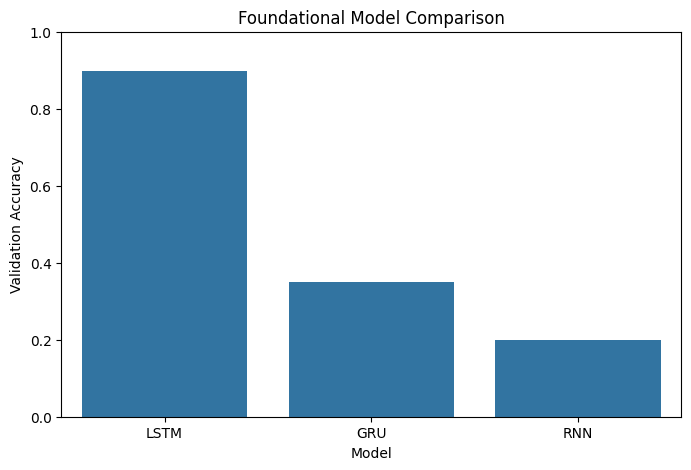

In [116]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=result_df,
    x='Model',
    y='Validation Accuracy'
)
plt.ylim(0, 1)
plt.title('Foundational Model Comparison')
plt.ylabel('Validation Accuracy')
plt.show()


## 7. Phase 2 — Advanced Bidirectional Models

In Phase 2, we enhance the best-performing foundational recurrent architectures
by making them bidirectional.

We will build and compare:

1. Bidirectional LSTM
2. Bidirectional GRU

Both models will use:
- 300-dimensional word embeddings
- Two stacked bidirectional recurrent layers
- Dropout regularization
- Sparse categorical cross-entropy loss
- Adam optimizer

The validation dataset will be used during training for model monitoring and
early stopping.

The test dataset will remain completely separate and will be used only once
for the final evaluation of the selected model.

### 7.1 Model 4 — Bidirectional GRU

A stacked Bidirectional GRU is used to process the input sequence in both
forward and backward directions.

GRU provides a simpler recurrent structure than LSTM while still being able
to capture long-term dependencies.

In [117]:
BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=max_length),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiGRU.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

BiGRU.summary()


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [118]:
BiGRU_history = BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_validation_sequence, validation_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()]
)

BiGRU_val_loss, BiGRU_val_accuracy = BiGRU.evaluate(
    padded_validation_sequence,
    validation_labels,
    verbose=0
)

print(f'BiGRU Validation Loss: {BiGRU_val_loss:.4f}')
print(f'BiGRU Validation Accuracy: {BiGRU_val_accuracy:.4f}')


Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.5621 - loss: 1.0371 - val_accuracy: 0.8995 - val_loss: 0.3442
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9149 - loss: 0.2385 - val_accuracy: 0.9190 - val_loss: 0.2269
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9439 - loss: 0.1477 - val_accuracy: 0.9310 - val_loss: 0.1960
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9591 - loss: 0.1134 - val_accuracy: 0.9270 - val_loss: 0.2324
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9703 - loss: 0.0814 - val_accuracy: 0.9280 - val_loss: 0.2445
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9762 - loss: 0.0655 - val_accuracy: 0.9175 - val_loss: 0.2742
BiGRU Validation Loss: 0.1960
BiGRU Validation Accuracy: 0.9310


### 7.2 Model 5 — Bidirectional LSTM

A stacked Bidirectional LSTM is used to process the sequence in both forward
and backward directions, allowing the model to capture contextual information
from both sides of the text.

In [119]:
BiLSTM = Sequential([
    Embedding(input_dim=max_words, output_dim=300, input_length=50),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

BiLSTM.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
BiLSTM.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [120]:
BiLSTM_history = BiLSTM.fit(
    padded_train_sequence, train_labels,
    validation_data=(padded_validation_sequence, validation_labels),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[make_early_stopping()]
)

BiLSTM_val_loss, BiLSTM_val_accuracy = BiLSTM.evaluate(
    padded_validation_sequence, validation_labels, verbose=0
)

print(f"BiLSTM Validation Loss: {BiLSTM_val_loss:.4f}")
print(f"BiLSTM Validation Accuracy: {BiLSTM_val_accuracy:.4f}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.5942 - loss: 1.0478 - val_accuracy: 0.8915 - val_loss: 0.3430
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9130 - loss: 0.2858 - val_accuracy: 0.9110 - val_loss: 0.2715
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9366 - loss: 0.1823 - val_accuracy: 0.9040 - val_loss: 0.2870
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9509 - loss: 0.1340 - val_accuracy: 0.9190 - val_loss: 0.2540
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9625 - loss: 0.1062 - val_accuracy: 0.9120 - val_loss: 0.2892
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9675 - loss: 0.0871 - val_accuracy: 0.9155 - val_loss: 0.2909
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9722 - loss: 0.0732 - val_accuracy: 0.9075 - val_loss: 0.2993
BiLSTM Validation Loss: 0.2540
BiLSTM Validation Accuracy: 0.9190


### 7.3 Phase 2 Model Comparison

The Bidirectional LSTM and Bidirectional GRU models are compared using their
validation performance.

The model with the better validation accuracy will be selected as the final
model for testing.

In [121]:
phase2_results = pd.DataFrame({
    'Model': ['BiLSTM', 'BiGRU'],
    'Validation Loss': [
        BiLSTM_val_loss,
        BiGRU_val_loss
    ],
    'Validation Accuracy': [
        BiLSTM_val_accuracy,
        BiGRU_val_accuracy
    ]
})

phase2_results = phase2_results.sort_values(
    by='Validation Accuracy',
    ascending=False
).reset_index(drop=True)

phase2_results

,Model,Validation Loss,Validation Accuracy
0,BiGRU,0.196042,0.931
1,BiLSTM,0.254044,0.919


### 7.4 Training Curves

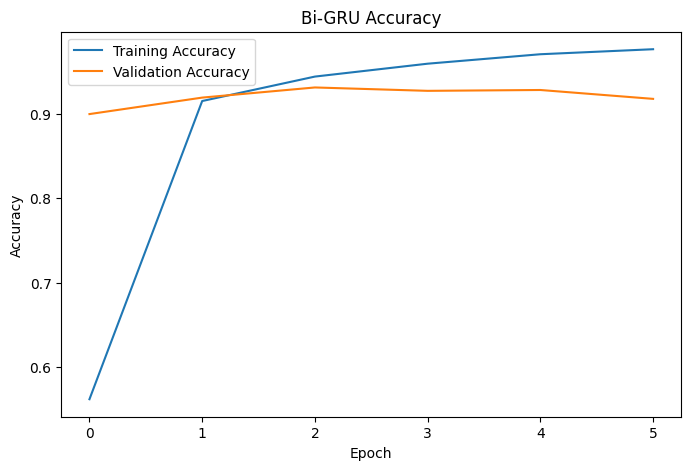

In [130]:
history_df = pd.DataFrame(BiGRU_history.history)

plt.figure(figsize=(8, 5))
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Bi-GRU Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


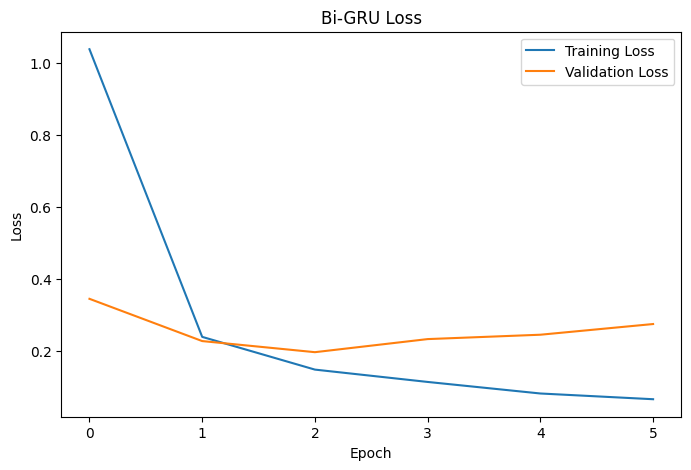

In [131]:
plt.figure(figsize=(8, 5))
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Bi-GRU Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## 8. Final Evaluation on the Unseen Test Set

The test set has not been used for training, early stopping, or model selection. We now evaluate the final Bi-GRU on the test set.

In [127]:
BiGRU_test_loss, BiGRU_test_accuracy = BiGRU.evaluate(
    padded_test_sequence,
    test_labels,
    verbose=1
)

print(f'BiGRU Test Loss: {BiGRU_test_loss:.4f}')
print(f'BiGRU Test Accuracy: {BiGRU_test_accuracy:.4f}')


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9155 - loss: 0.2253
BiGRU Test Loss: 0.2253
BiGRU Test Accuracy: 0.9155


### 8.1 Final Model Confusion Matrix

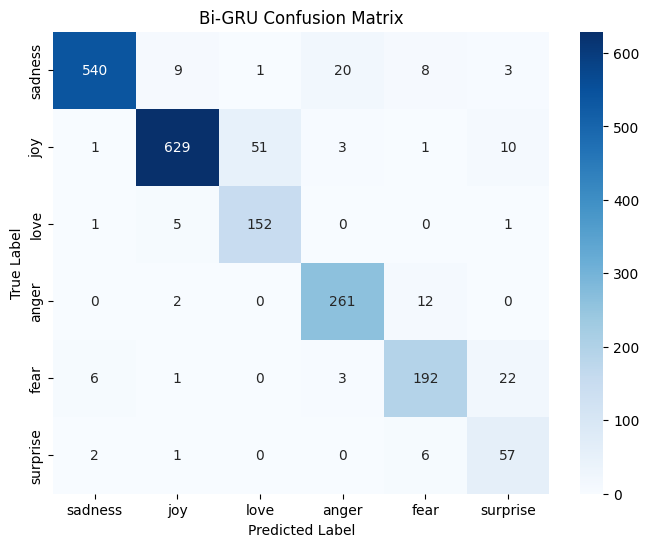

In [128]:
BiGRU_predictions = np.argmax(
    BiGRU.predict(padded_test_sequence, verbose=0),
    axis=1
)

cm = confusion_matrix(test_labels, BiGRU_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title('Bi-GRU Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### 8.2 Classification Report

In [129]:
print(
    classification_report(
        test_labels,
        BiGRU_predictions,
        target_names=label_names,
        digits=4
    )
)


              precision    recall  f1-score   support

     sadness     0.9818    0.9294    0.9549       581
         joy     0.9722    0.9050    0.9374       695
        love     0.7451    0.9560    0.8375       159
       anger     0.9094    0.9491    0.9288       275
        fear     0.8767    0.8571    0.8668       224
    surprise     0.6129    0.8636    0.7170        66

    accuracy                         0.9155      2000
   macro avg     0.8497    0.9101    0.8737      2000
weighted avg     0.9257    0.9155    0.9182      2000



## 9. Final Predictions

Test the winning Bi-GRU on a few example sentences.

In [132]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


## 10. Save Model & Tokenizer

Export the trained model and tokenizer artifacts for **Streamlit deployment**.  
These files will be loaded inside the Streamlit app to perform emotion classification on user input.

In [135]:
import os
import pickle

model_dir = 'ArtifactsFinal'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)